<img src="assets/header.png" alt="Header" style="display: block; margin: auto; width: 50%;">


# 📚 Import Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
from sklearn.preprocessing import StandardScaler

In [11]:
from scipy.stats.mstats import winsorize
from scipy.stats import mstats

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
import pandas as pd
import numpy as np

---

# 💧 Exploratory Data Analysis (EDA) dan Visualisasi Awal Data Kualitas Air
Tahapan ini berfokus pada pemahaman awal terhadap struktur, persebaran, dan kualitas data. Kami akan melakukan EDA serta membuat visualisasi yang menarik dan informatif.

## 📥 Memuat dan Menampilkan Informasi Awal Dataset

In [3]:
water_df = pd.read_csv('./data/water_potability.csv')

In [5]:
print('****'*10)
print(f'Dataframe has {water_df.shape[0]} Rows, {water_df.shape[1]} Columns')
print('****'*10)

water_df.head().style.set_properties(**{'background-color': '#A2DBFA',
                                    'color': 'black',
                                    'border': '1.5px  solid black'}).bar(color='#F3F1F5', 
                                                                         vmin=100_000, 
                                                                         subset=['Potability'])

****************************************
Dataframe has 3276 Rows, 10 Columns
****************************************


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,nan,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,nan,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,nan,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


📌 **Penjelasan** : 
- Dataset berhasil dimuat dengan ukuran 3276 baris dan 10 kolom
- Tampilan data menggunakan styling berwarna biru muda (#A2DBFA) untuk memudahkan pembacaan
- Kolom yang ada meliputi berbagai parameter kualitas air dan target 'Potability'

## 🧾 Melihat Sample Data dan Statistik Deskriptif

In [6]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


📌 **Penjelasan** : 
- Semua kolom memiliki tipe data float64
- Terdapat missing values di beberapa kolom
- Memory usage teroptimasi

In [7]:
water_df.describe().T.style.bar(subset=['mean'], color='#E68193')\
                            .background_gradient(subset=['std'], cmap='mako_r')\
                             .background_gradient(subset=['50%'], cmap='mako')

,count,mean,std,min,25%,50%,75%,max
ph,2785.000000,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.000000,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.000000,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.000000,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.000000,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.000000,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.000000,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.000000,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.000000,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.000000,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


📌 **Penjelasan** : 
- Visualisasi dengan gradient warna menunjukkan variasi standar deviasi
- Mean dan median ditampilkan dengan bar chart berwarna merah muda (#E68193)

## 🧩 Cek Nilai Unik, Missing Values, dan Duplikasi

In [8]:
# Menampilkan jumlah nilai unik dalam dataset
print("\nJumlah Nilai Unik per Kolom:")
print(water_df.nunique())


Jumlah Nilai Unik per Kolom:
ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64


📌 **Penjelasan** : 
- Mayoritas parameter memiliki nilai unik maksimal (3276), menunjukkan presisi pengukuran tinggi
- pH dan Sulfate memiliki nilai unik lebih sedikit karena missing values
- Target variable bersifat binary, sesuai untuk klasifikas

In [9]:
# Mengecek jumlah missing values
print("\nMissing Values dalam Dataset:")
print(water_df.isnull().sum())


Missing Values dalam Dataset:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


📌 **Penjelasan** : 
- pH: 491 missing values
- Sulfate: 781 missing values
- Trihalomethanes: 162 missing values

In [10]:
# Menampilkan data duplikat
print("\nData Duplikat dalam Dataset:")
print(water_df.duplicated().sum())


Data Duplikat dalam Dataset:
0


📌 **Penjelasan** : 
- Tidak di temukan data duplikat 

# 📊 Visualisasi Data Awal

## 📈 Visualisasi Distribusi Target (`Potability`)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16396\1196248340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=water_df, ax=ax1, palette='husl', hue=None, legend=False)


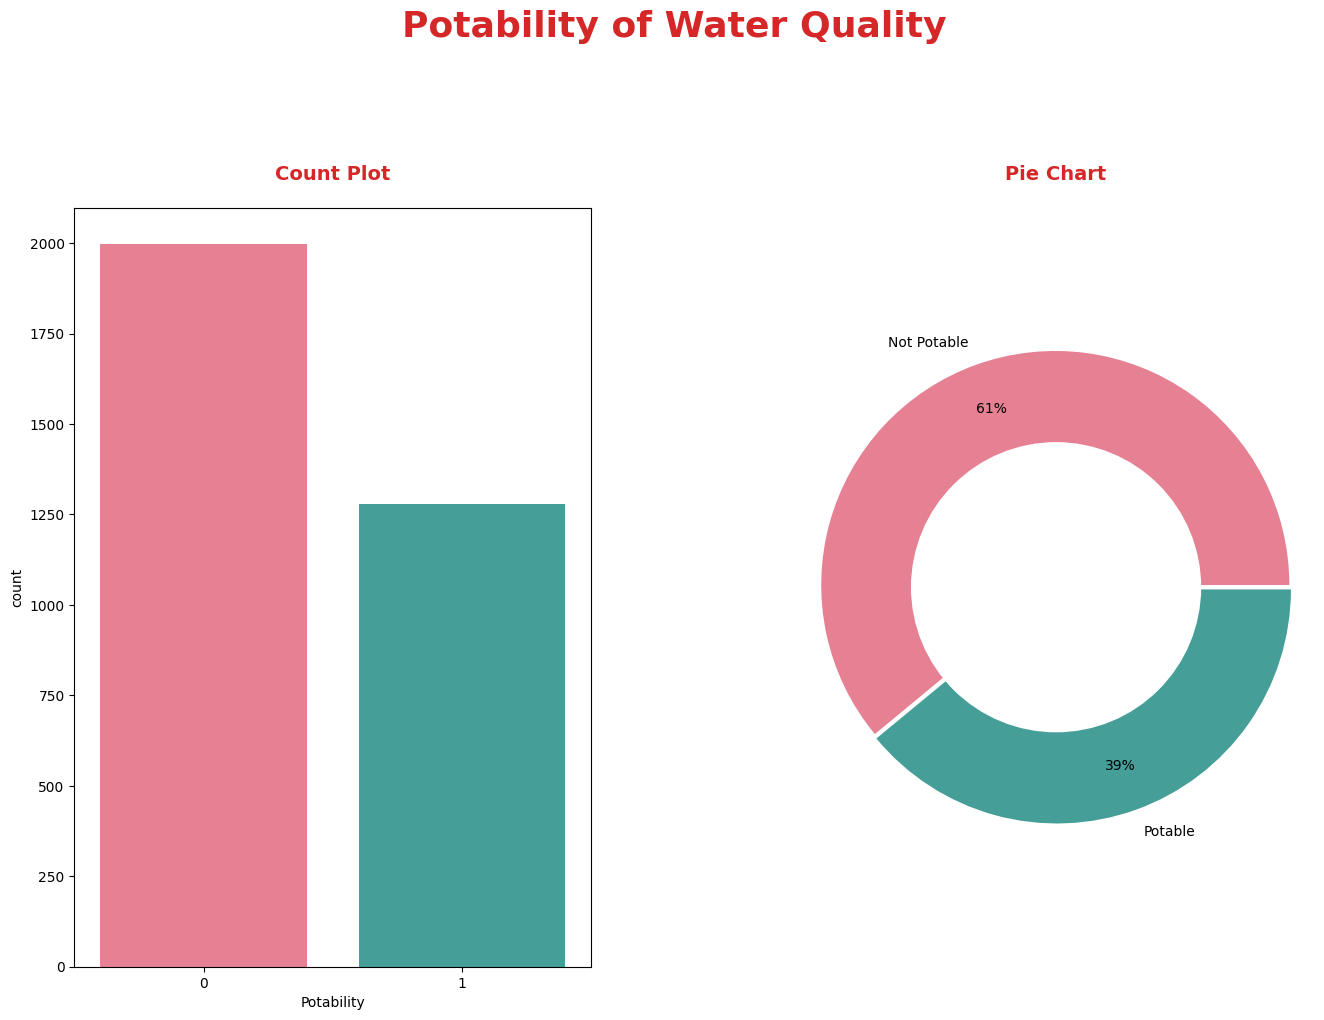

In [13]:
#  Define theme colors if not already defined
theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 11))
fig.suptitle('Potability of Water Quality', size=26, color=theme[3], weight='bold')
axs = [ax1, ax2]

# Count Plot
sns.countplot(x='Potability', data=water_df, ax=ax1, palette='husl', hue=None, legend=False)
ax1.set_title('Count Plot', size=14, color=theme[3], weight='bold', pad=20)

# Pie Chart (Doughnut)
names = ["Not Potable", "Potable"]
values = water_df['Potability'].value_counts().sort_index()
colors = ["#E68193", "#459E97"]
explode = (0.01, 0.01)

# Pie chart
ax2.pie(x=values, labels=names, colors=colors, autopct='%1.0f%%', pctdistance=0.8, explode=explode)

# Doughnut center
centre_circle = plt.Circle((0, 0), 0.62, fc='white')
ax2.add_artist(centre_circle)
ax2.axis('equal')
ax2.set_title('Pie Chart', size=14, color=theme[3], weight='bold', pad=20)

# Layout
plt.subplots_adjust(left=None, bottom=None, right=None, top=0.8, wspace=0.4, hspace=None)
plt.show()


### 🧠 Insight
- Data ini menunjukkan **tantangan besar dalam ketersediaan air bersih**.
- Penting untuk meneliti lebih lanjut faktor-faktor penyebab air tidak layak, seperti:
  - Kandungan kimia berbahaya
  - Tingkat pH tidak seimbang
  - Polusi lingkungan

## 🪄 Distribusi Fitur berdasarkan Potability

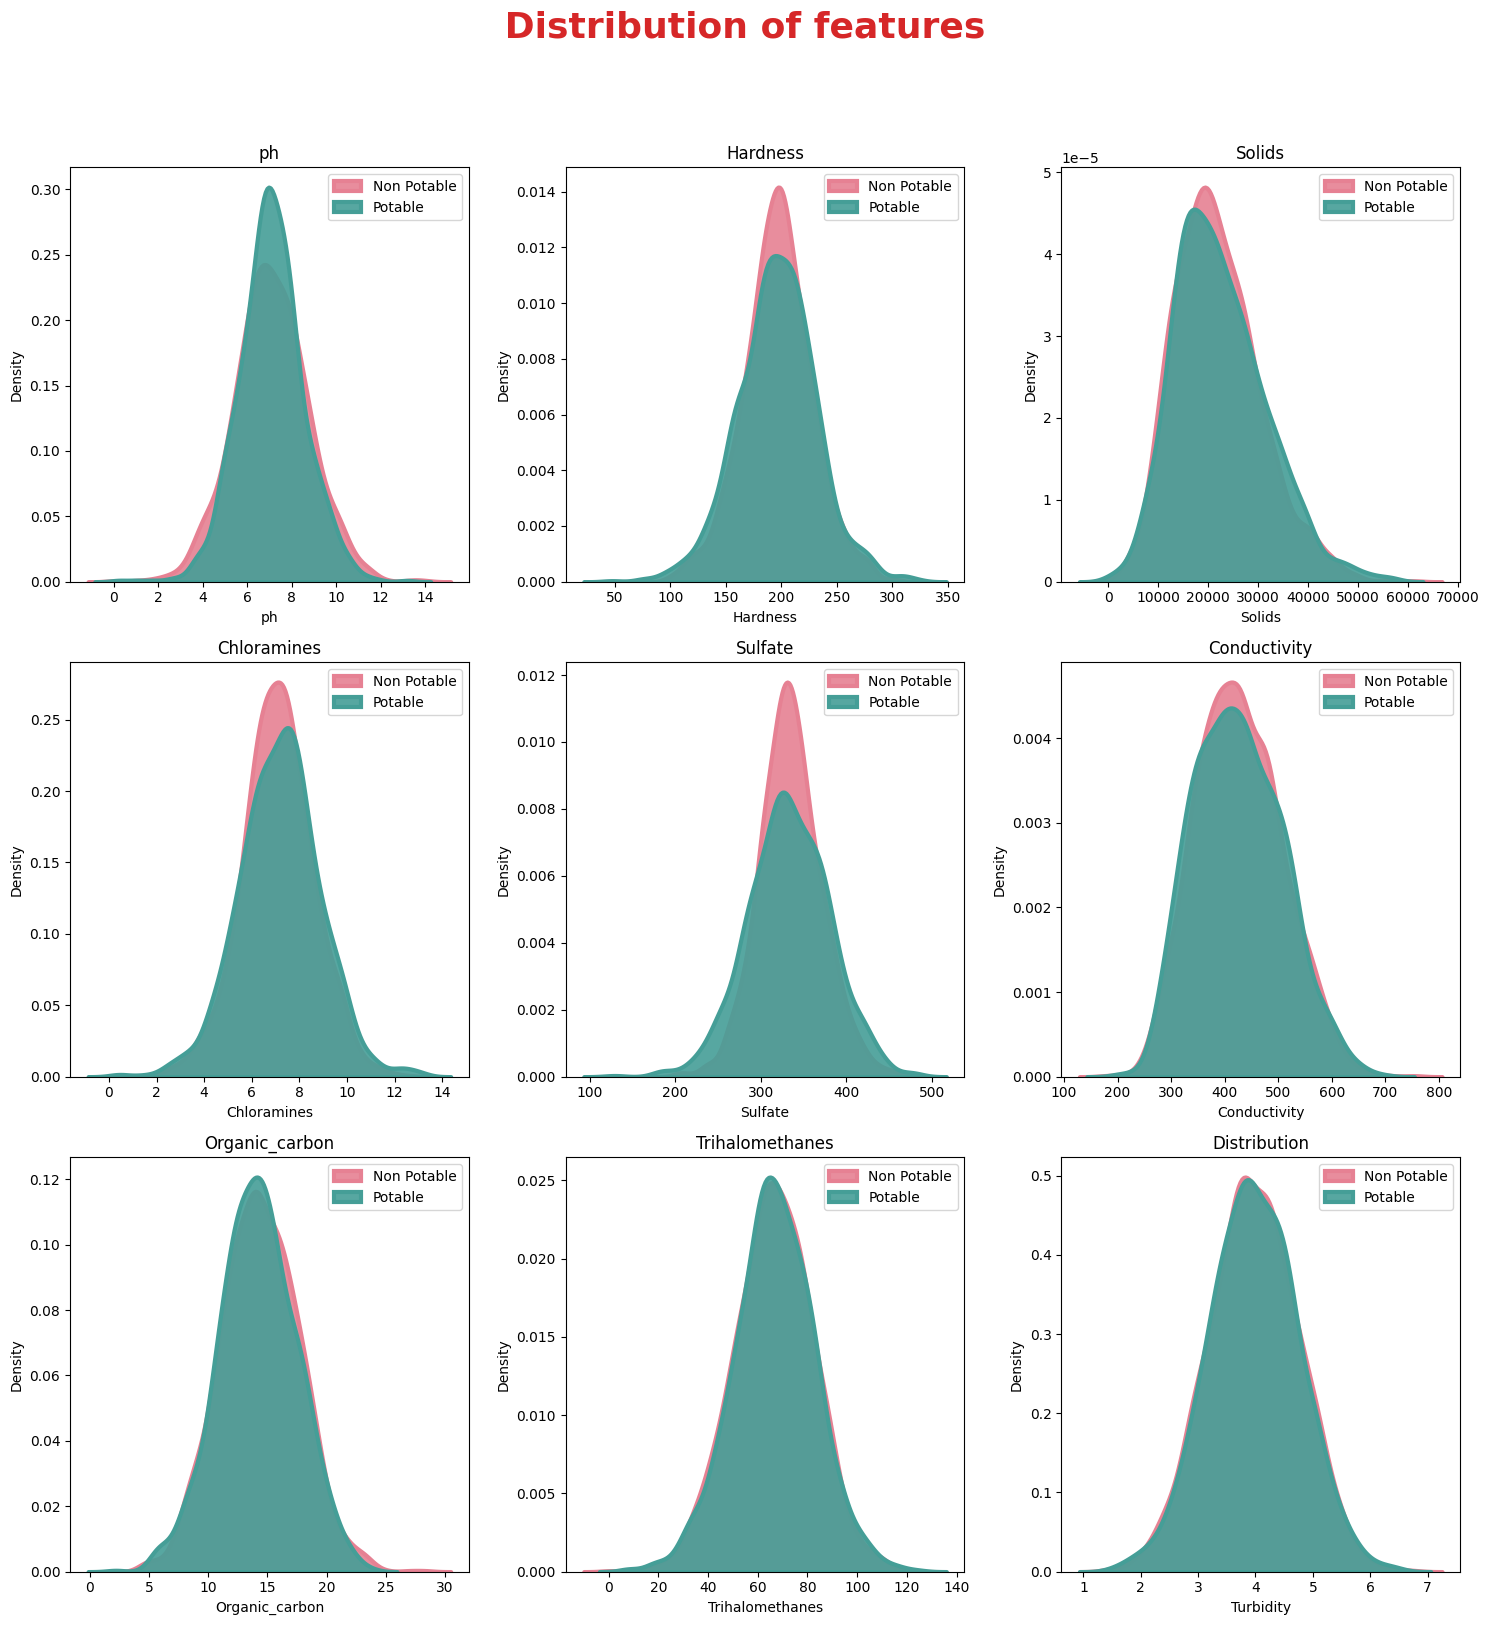

In [14]:
non_potable = water_df.query("Potability == 0")
potable = water_df.query("Potability == 1")

plt.figure(figsize = (15,15))
for ax, col in enumerate(water_df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    plotting = sns.kdeplot(x = non_potable[col], label = "Non Potable",fill=True, common_norm=False, color="#E68193",alpha=.9, linewidth=3)
    plotting = sns.kdeplot(x = potable[col], label = "Potable",fill=True, common_norm=False, color="#459E97",alpha=.9, linewidth=3)
    plt.legend()
plt.tight_layout()
plt.title('Distribution')
plotting.figure.suptitle(' Distribution of features ',y=1.08, size = 26, color = theme[3], weight='bold');

### 🧠 Kesimpulan Umum
- Beberapa fitur seperti pH, sulfate, solids, dan turbidity tampak cukup berbeda distribusinya antara air yang layak dan tidak.
- Fitur-fitur ini bisa sangat relevan untuk pemodelan prediksi kelayakan air 💡




## ♨️ Korelasi antar Fitur

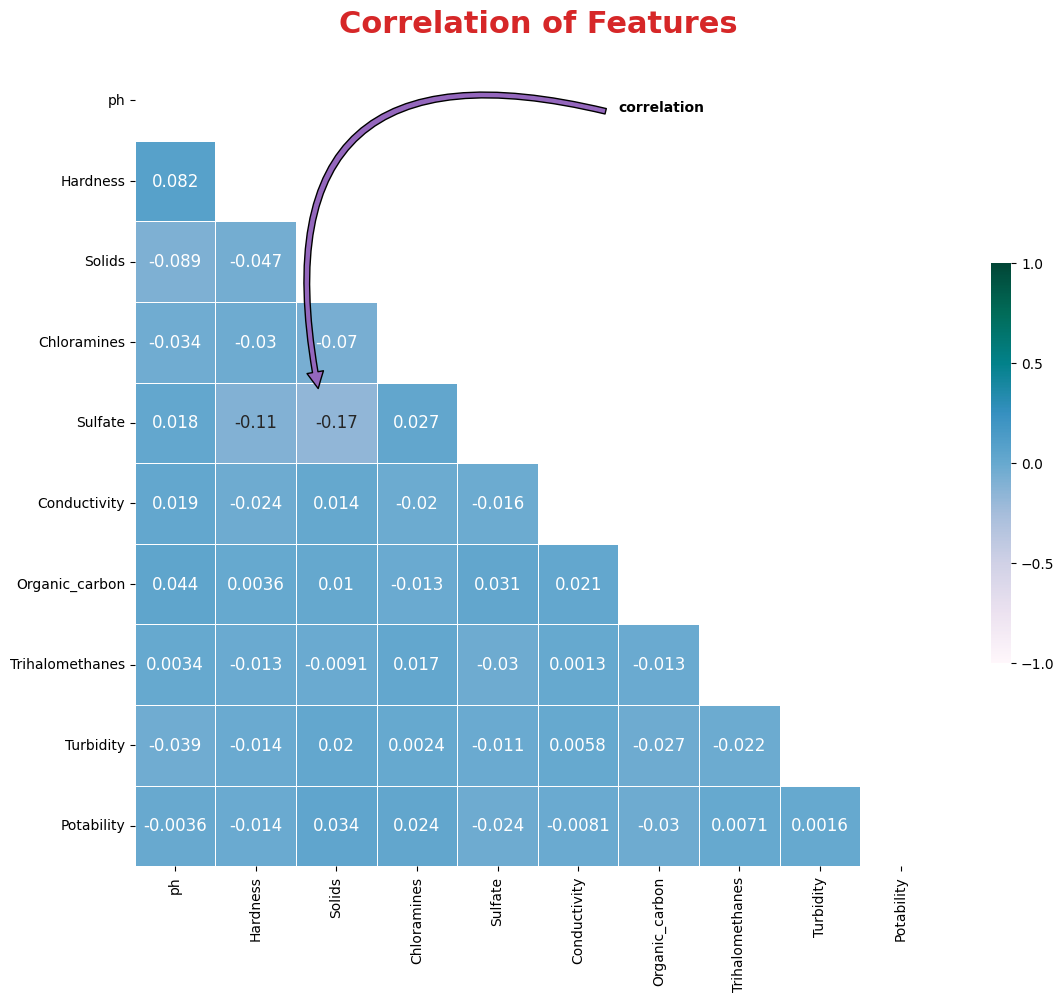

In [15]:
# Define theme colors if not already defined
theme = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
         '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create correlation matrix mask
mask = np.zeros_like(water_df.corr(), dtype=bool)  # Changed from np.bool to bool
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(13, 13))

heatmap = sns.heatmap(water_df.corr(),
                      mask=mask,
                      square=True,
                      linewidths=.5,
                      cmap='PuBuGn',
                      cbar_kws={'shrink': .4, "ticks": [-1, -.5, 0, 0.5, 1]},
                      vmin=-1,
                      vmax=1,
                      annot=True,
                      annot_kws={"size": 12})

# Add column names as labels
ax.set_yticklabels(water_df.corr(), rotation=0)
ax.set_xticklabels(water_df.corr())

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

# Add correlation annotation
ax.annotate('correlation',
           fontsize=10,
           fontweight='bold',
           xy=(2.3, 4.2),
           xycoords='data',
           xytext=(0.6, 0.95),
           textcoords='axes fraction',
           arrowprops=dict(
               facecolor=theme[4],
               shrink=0.025,
               connectionstyle='arc3, rad=0.80'),
           horizontalalignment='left',
           verticalalignment='top')

ax.set_title('Correlation of Features', size=22, color=theme[3], weight='bold', pad=20)

plt.show()

### 🎯 Insight Penting
- Sebagian besar fitur memiliki korelasi rendah atau tidak signifikan satu sama lain, menandakan bahwa fitur-fitur dalam dataset ini relatif independen.
- Tidak ada hubungan linier yang kuat dengan fitur Potability, menunjukkan bahwa pendekatan machine learning mungkin diperlukan untuk memahami pola kompleks.



---

# 🧹 Tahap Data Preprocessing
Agar model dapat belajar secara optimal, penting untuk memastikan data bersih, seimbang, dan informatif. Berikut adalah langkah-langkah preprocessing yang telah dilakukan:

### 🔍 Menghapus Nilai Kosong (Missing Values)

In [4]:
water_df = water_df.dropna()

📌 Setelah penghapusan, dilakukan pengecekan kembali untuk memastikan semua kolom bersih:

In [5]:
water_df.isnull().sum()


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

📄 **Hasil:**
```
Semua fitur memiliki 0 nilai kosong. Dataset sudah bersih. ✅
```

### ⚖️ Menyeimbangkan Distribusi Kelas (Upsampling)

Dataset asli memiliki **ketidakseimbangan kelas**, di mana lebih banyak data air *tidak layak minum* (`Potability = 0`) dibanding yang *layak minum* (`Potability = 1`). Hal ini dapat menyebabkan model bias terhadap kelas mayoritas.

🧪 **Solusi:** Lakukan *upsampling* terhadap kelas minoritas (Potability = 1) dengan teknik *resampling* agar jumlahnya setara dengan kelas mayoritas.

In [7]:
# Menyeimbangkan kelas (upsampling class 1)
from sklearn.utils import resample, shuffle
df_0 = water_df[water_df['Potability'] == 0]
df_1 = water_df[water_df['Potability'] == 1]
df_1_upsampled = resample(df_1, replace=True, n_samples=len(df_0), random_state=42)
df_balanced = shuffle(pd.concat([df_0, df_1_upsampled]), random_state=42)

🎯 **Tujuan:** Membuat model tidak berat sebelah dan adil dalam memprediksi kedua kelas.

### 📊 Visualisasi Distribusi Kelas Setelah Penyeimbangan

Untuk memastikan bahwa kelas sudah seimbang setelah upsampling, dibuat diagram pie:

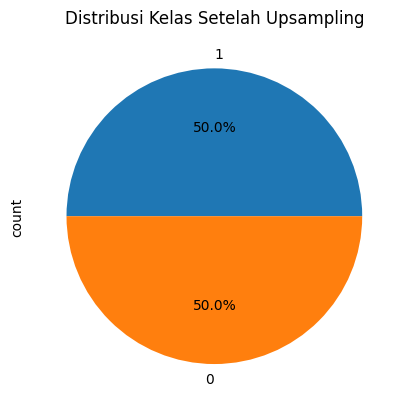

In [9]:
# Cek distribusi kelas
df_balanced.Potability.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Kelas Setelah Upsampling")
plt.show()

🟢 Hasil: Masing-masing kelas (0 & 1) memiliki distribusi **50.0%**, menandakan bahwa proses balancing berhasil.

### 📈 Korelasi Antar Fitur 🔗

Heatmap korelasi digunakan untuk melihat sejauh mana antar fitur saling berkaitan, termasuk terhadap target `Potability`.

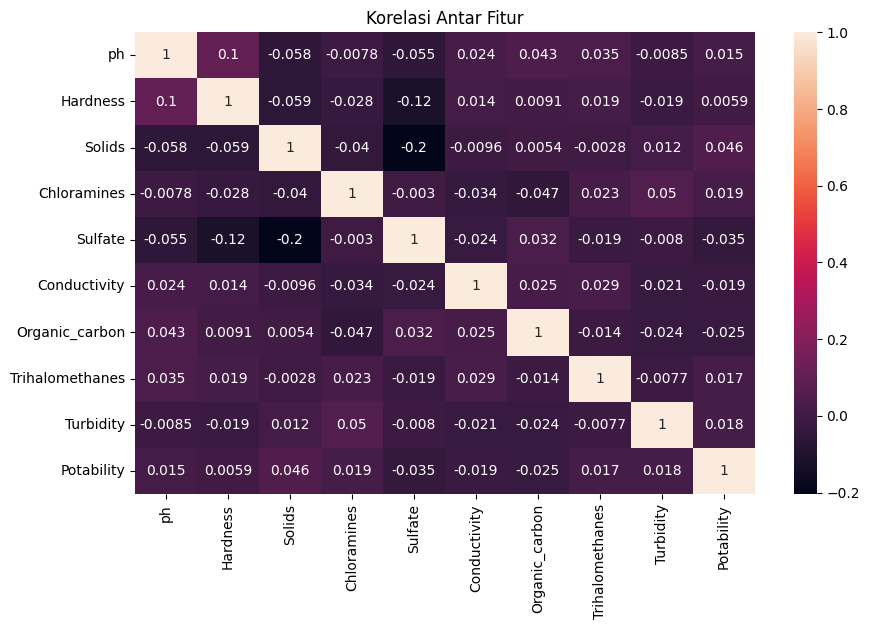

In [10]:
# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df_balanced.corr(), annot=True)
plt.title("Korelasi Antar Fitur")
plt.show()

### 🔬 Visualisasi Sebaran Fitur Terhadap Potability

Plot scatter membantu memvisualisasikan hubungan antara dua fitur (misal: `ph` dan `Hardness`) dengan label `Potability`.

<Axes: xlabel='ph', ylabel='Hardness'>

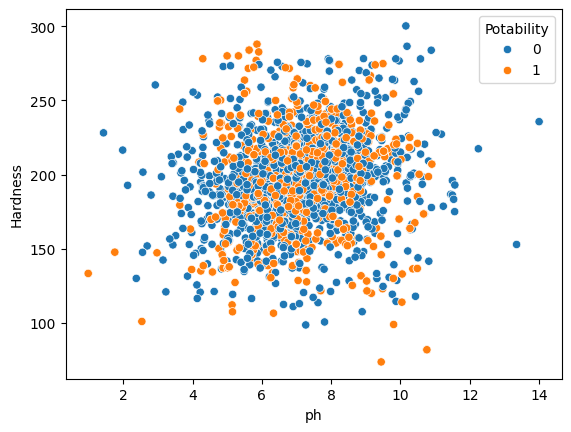

In [11]:
sns.scatterplot(x=df_balanced["ph"], y=df_balanced["Hardness"], hue=df_balanced.Potability,
data=df_balanced)

<Axes: xlabel='ph', ylabel='Hardness'>

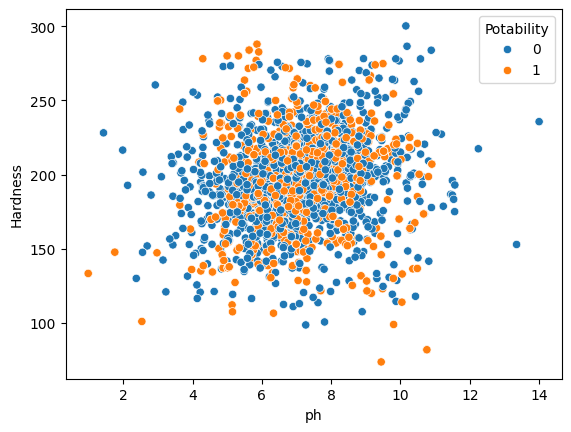

In [12]:
sns.scatterplot(x=df_balanced["ph"], y=df_balanced["Hardness"], hue=df_balanced.Potability,
data=df_balanced)

📍 **Tujuan:** Menemukan pola yang mungkin tidak terlihat dari tabel korelasi.

### 📌 Korelasi Fitur terhadap Target `Potability`

Menampilkan fitur mana yang **paling berpengaruh terhadap prediksi air layak minum** berdasarkan nilai absolut korelasi.

In [13]:
df_balanced.corr().abs()['Potability'].sort_values(ascending = False)

Potability         1.000000
Solids             0.045535
Sulfate            0.035401
Organic_carbon     0.025118
Chloramines        0.018753
Conductivity       0.018581
Turbidity          0.017854
Trihalomethanes    0.017463
ph                 0.014620
Hardness           0.005864
Name: Potability, dtype: float64

🔎 **Output:** Menyusun fitur berdasarkan pengaruhnya terhadap `Potability`, dari yang paling penting ke yang kurang relevan.

MOdeling

In [14]:
# === DEFINISI FITUR DAN TARGET ===
X = df_balanced.drop('Potability', axis=1)
y = df_balanced['Potability']

In [15]:
# === SCALING FITUR ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# === SPLIT DATA TRAIN-TEST ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y)

In [17]:
# === INISIALISASI MODEL (SEBELUM TUNING) ===
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

print("=== Akurasi Sebelum Tuning ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, y_pred):.2f}")

=== Akurasi Sebelum Tuning ===
Logistic Regression: 0.51
KNN: 0.75
Naive Bayes: 0.53
Decision Tree: 0.81


In [18]:
# === INISIALISASI UNTUK TUNING ===
results = {}
best_models = {}

In [19]:
# === LOGISTIC REGRESSION TUNING ===
print("\n🔍 Sedang melakukan tuning pada model Logistic Regression ...")
lr = LogisticRegression()
param_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid_lr = GridSearchCV(lr, param_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_models['Logistic Regression'] = grid_lr.best_estimator_
results['Logistic Regression'] = grid_lr.best_score_

# === KNN TUNING ===
print("\n🔍 Sedang melakukan tuning pada model KNN ...")
knn = KNeighborsClassifier()
param_knn = {'n_neighbors': np.arange(1, 50), 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)
best_models['KNN'] = grid_knn.best_estimator_
results['KNN'] = grid_knn.best_score_

# === NAIVE BAYES (TIDAK PERLU TUNING) ===
print("\n🔍Tidak melakukan tuning Naive Bayes ...")
nb = GaussianNB()
nb.fit(X_train, y_train)
best_models['Naive Bayes'] = nb
results['Naive Bayes'] = nb.score(X_train, y_train)

# === DECISION TREE TUNING ===
print("\n🔍 Sedang melakukan tuning pada model  Decision Tree ...")
dt = DecisionTreeClassifier()
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(1, 50),
    'min_samples_leaf': [1, 2, 4, 5, 10, 20, 30, 40, 80, 100]
}
grid_dt = GridSearchCV(dt, param_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_models['Decision Tree'] = grid_dt.best_estimator_
results['Decision Tree'] = grid_dt.best_score_



🔍 Sedang melakukan tuning pada model Logistic Regression ...

🔍 Sedang melakukan tuning pada model KNN ...

🔍Tidak melakukan tuning Naive Bayes ...

🔍 Sedang melakukan tuning pada model  Decision Tree ...



📊 Evaluasi Semua Model di Test Set:

Model: Logistic Regression
Akurasi: 50.83%
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       120
           1       0.51      0.48      0.50       120

    accuracy                           0.51       240
   macro avg       0.51      0.51      0.51       240
weighted avg       0.51      0.51      0.51       240



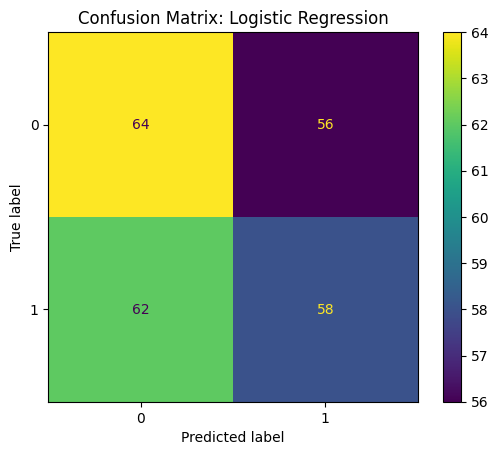


Model: KNN
Akurasi: 80.83%
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       120
           1       0.79      0.83      0.81       120

    accuracy                           0.81       240
   macro avg       0.81      0.81      0.81       240
weighted avg       0.81      0.81      0.81       240



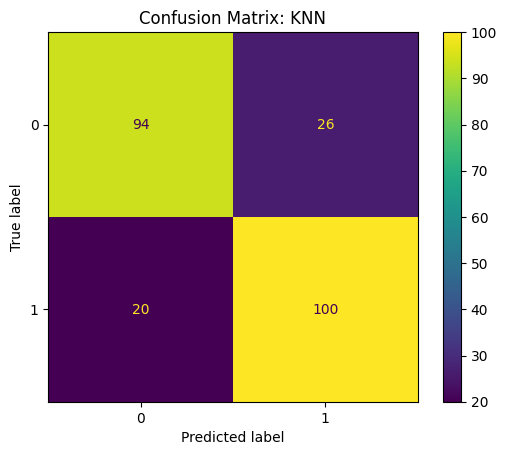


Model: Naive Bayes
Akurasi: 52.92%
              precision    recall  f1-score   support

           0       0.52      0.62      0.57       120
           1       0.54      0.44      0.48       120

    accuracy                           0.53       240
   macro avg       0.53      0.53      0.53       240
weighted avg       0.53      0.53      0.53       240



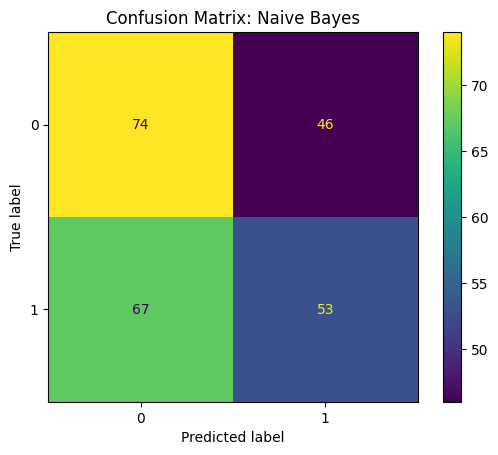


Model: Decision Tree
Akurasi: 78.33%
              precision    recall  f1-score   support

           0       0.84      0.70      0.76       120
           1       0.74      0.87      0.80       120

    accuracy                           0.78       240
   macro avg       0.79      0.78      0.78       240
weighted avg       0.79      0.78      0.78       240



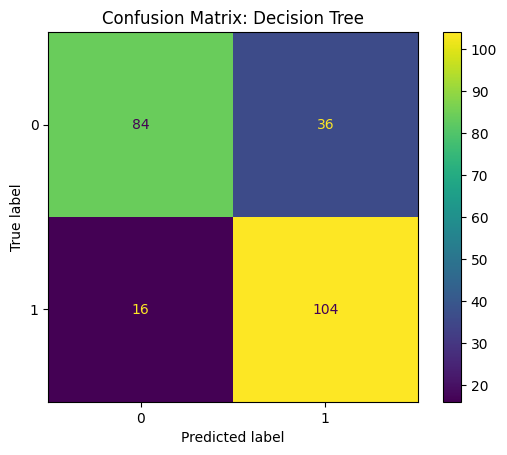

In [20]:
# Evaluasi semua model di test set
print("\n📊 Evaluasi Semua Model di Test Set:")
for name, model in best_models.items():
    print(f"\nModel: {name}")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Akurasi: {acc:.2f}%")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


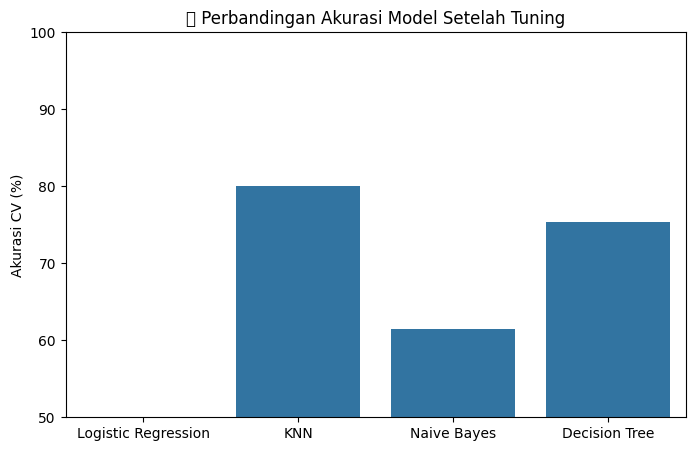

In [21]:
# Grafik perbandingan akurasi (CV)
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=[v*100 for v in results.values()])
plt.ylabel("Akurasi CV (%)")
plt.title("📈 Perbandingan Akurasi Model Setelah Tuning")
plt.ylim(50, 100)
plt.show()

In [22]:
# Model terbaik
best_model_name = max(results, key=results.get)
print(f"\n✅ Model terbaik berdasarkan cross-validation adalah: {best_model_name} dengan akurasi {results[best_model_name]*100:.2f}%")


✅ Model terbaik berdasarkan cross-validation adalah: KNN dengan akurasi 80.00%
